In [1]:
import numpy as np
import math
from sympy import *
from scipy import integrate
import matplotlib.pyplot as plt
import random
import time

In [2]:
def TDT(b,c):
    if b+c == 0:
        return 0
    else:
        return ((b-c)**2)/(b+c)

In [3]:
def LS(b,c,N): 
    stat = TDT(b,c)
    M = stat; m = stat
    
    if b >= 2:
        v = [TDT(b-2,c), TDT(b-2,c+1), TDT(b-2,c+2)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b >= 1:
        v = [TDT(b-1,c), TDT(b-1,c+1)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b >= 1 and c >= 1:
        v = TDT(b-1,c-1)
        M = max([v,M])
        m = min([v,m])
    if c >= 2:
        v = [TDT(b,c-2), TDT(b+1,c-2), TDT(b+2,c-2)]
        M = max([max(v),M])
        m = min([min(v),m])
    if c >= 1:
        v = [TDT(b,c-1), TDT(b+1,c-1)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b+c <= 2*N-2:
        v = [TDT(b+1,c+1), TDT(b,c+2), TDT(b+2,c)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b+c <= 2*N-1:
        v = [TDT(b,c+1), TDT(b+1,c)]
        M = max([max(v),M])
        m = min([min(v),m])
    if b+c <= 2*N-1 and b >= 1:
        v = TDT(b-1,c+2)
        M = max([v,M])
        m = min([v,m])
    if b+c <= 2*N-1 and c >= 1:
        v = TDT(b+2,c-1)
        M = max([v,M])
        m = min([v,m])
    
    return [M-stat, stat-m]

In [4]:
def d(x,b,c):
    if b >= x[0] and c >= x[1]:
        return math.ceil(((b+c)-(x[0]+x[1]))/2)
    elif b <= x[0] and c <= x[1]:
        return math.ceil(((x[0]+x[1])-(b+c))/2)
    else:
        return math.ceil(max([math.fabs(b-x[0]), math.fabs(c-x[1])])/2)

def ud(x,N): 
    sd = 10000
    for c in range(int(N/4)):
        s = 9+7*c
        for b in range(s,2*N-c+1):
            sd = min([d(x,b,c),d(x,b-2,c+2),sd])
    for b in range(int(N/4)):
        s = 9+7*b
        for c in range(s,2*N-b+1):
            sd = min([d(x,b,c),d(x,b+2,c-2),sd])
    return sd

In [5]:
def LP(x,eps,N,m): #M_{LP}
    u = np.zeros(m); v = np.zeros(m)
    scale = (8*(N-1)/N)/eps
    for i in range(m):
        u[i] = TDT(x[i][0],x[i][1])
        v[i] = u[i] + np.random.laplace(0,2*scale)
    return np.argmax(v)

def ELP(x,eps,N,m): #M_{ELP}
    u = np.zeros(m); v = np.zeros(m)
    scale = 2*(8*(N-1)/N)/eps
    for i in range(m):
        u[i] = TDT(x[i][0],x[i][1])
        v[i] = u[i] + np.random.laplace(0,scale)
    return np.argmax(v)

def EDLP(x,eps,N,m): #M_{EDLP}
    u = np.zeros(m); v = np.zeros(m)
    scale = 2*(8*(N-1)/N)/eps
    for i in range(m):
        u[i] = TDT(x[i][0],x[i][1])
        v[i] = u[i] + np.random.laplace(0,scale)
    return np.argmax(v)

In [6]:
def h4(z):
    return np.sqrt(2)/(math.pi*(z**4+1))

def cdf(x,h):
    return integrate.quad(h,-oo,x)

def noise(h,CDF):
    rr = np.random.rand()
    l = 0; r = 2000
    while(1):
        t = (int)((l+r)/2)
        if CDF[t] >= rr:
            r = t
        else:
            l = t
        if r-l <= 1:
            z = (((l+r)/2)-1000)/100
            break
    return z

def SPS(x,eps,N,m,gamma,CDF): #M_{SPS}, ud(x), Two-Sided noise #N = 150, gamma = 4
    GS = 8*(N-1)/N; lbeta = math.log(GS/max(LS(91,209,N)))/27 #math.log(2*GS/(max(LS(42,258,N))+max(LS(135,165,N))))/27
    alpha = eps/(2*((gamma-1)**((gamma-1)/gamma)))
    beta = eps/(2*(gamma-1)); lbeta = min(lbeta,beta/m)
    k = 1 - m*lbeta/(2*beta)
    u = np.zeros(m); v = np.zeros(m)
    s = np.zeros(m)
    
    for i in range(m):
        u[i] = TDT(x[i][0],x[i][1])
        if max(LS(x[i][0],x[i][1],N)) > 6:
            s[i] = GS
        else:
            s[i] = GS*math.exp(-lbeta*ud(x[i],N))
            
    S = max(s)
    for i in range(m):
        v[i] = u[i] + (S/(k*alpha))*noise(h4,CDF)
    
    return np.argmax(v)

def ESPS(x,eps,N,m,gamma,CDF): #M_{ESPS}, ud(x), Two-Sided noise #N=150, gamma = 4
    GS = 2*(8*(N-1)/N); lbeta = math.log(GS/(max(LS(42,258,N))+max(LS(135,165,N))))/27 #math.log(GS/(2*max(LS(91,209,N))))/27
    alpha = eps/(2*((gamma-1)**((gamma-1)/gamma)))
    beta = eps/(2*(gamma-1)); lbeta = min(lbeta,beta/m);
    k = 1 - m*lbeta/(2*beta)
    u = np.zeros(m); v = np.zeros(m)
    s = np.zeros(m)
    
    flag = 0; sd = 10000
    for i in range(m):
        u[i] = TDT(x[i][0],x[i][1])
        b1 = x[i][0]; c1 = x[i][1]
        ls1 = max(LS(b1,c1,N))
        for j in range(i+1,m):
            b2 = x[j][0]; c2 = x[j][1]
            ls2 = max(LS(b2,c2,N))
            if ls1 + ls2 > 12:
                flag = 1; break
            else:
                sd = min([math.ceil((12-ls1-ls2)*(b1+c1)*(b2+c2)/(32*(b1+c1+b2+c2)))+1, sd])
            
    if flag == 1:
        S = GS
    else:
        S = GS*math.exp(-lbeta*sd)
            
    for i in range(m):
        v[i] = u[i] + (S/(2*k*alpha))*noise(h4,CDF)
    
    return np.argmax(v)

def EDSPS(x,eps,N,m,gamma,CDF): #M_{EDSPS}, ud(x), Two-Sided noise #N=150, gamma = 4
    GS = 2*(8*(N-1)/N); lbeta = math.log(GS/(max(LS(42,258,N))+max(LS(135,165,N))))/27 #math.log(GS/(2*max(LS(91,209,N))))/27
    alpha = eps/(2*((gamma-1)**((gamma-1)/gamma)))
    beta = eps/(2*(gamma-1)); lbeta = min(lbeta,beta/m);
    k = 1 - m*lbeta/(2*beta)
    u = np.zeros(m); v = np.zeros(m)
    s = np.zeros(m)
    
    flag = 0; sd = 10000
    for i in range(m):
        u[i] = TDT(x[i][0],x[i][1])
        b1 = x[i][0]; c1 = x[i][1]
        ls1 = LS(b1,c1,N); ls10 = ls1[0]; ls11 = ls1[1]
        for j in range(i+1,m):
            b2 = x[j][0]; c2 = x[j][1]
            ls2 = LS(b2,c2,N); ls20 = ls2[0]; ls21 = ls2[1]
            if ls10 + ls21 > 12 or ls11 + ls20 > 12:
                flag = 1; break
            else:
                sd = min([math.ceil((12-ls10-ls21)*(b1+c1)*(b2+c2)/(32*(b1+c1+b2+c2)))+1, math.ceil((12-ls11-ls20)*(b1+c1)*(b2+c2)/(32*(b1+c1+b2+c2)))+1, sd])
                
    if flag == 1:
        S = GS
    else:
        S = GS*math.exp(-lbeta*sd)
            
    for i in range(m):
        v[i] = u[i] + (S/(2*k*alpha))*noise(h4,CDF)
    
    return np.argmax(v)

In [7]:
def generateData(N):
    d = np.zeros(2)
    s = np.random.binomial(int(2*N),2/3)
    d[0] = np.random.binomial(s,1/2)
    d[1] = s-d[0]
    return d

In [8]:
def accuracy(N,m,CDF):
    acc = np.zeros((7,6))
    x = np.zeros((m,2)); stats = np.zeros((m,2))
    
    for j in range(100):
        for i in range(m):
            x[i] = generateData(N)
            stats[i][0] = TDT(x[i][0],x[i][1])
            stats[i][1] = i
        sstats = sorted(stats,key=lambda x:(x[0]),reverse=True)
        sx = np.zeros((m,2))
        for i in range(m):
            sx[i] = x[int(sstats[i][1])]
        
        for i in range(7):
            a = LP(sx,3*(i+1),N,m); b = ELP(sx,3*(i+1),N,m); c = EDLP(sx,3*(i+1),N,m)
            d = SPS(sx,3*(i+1),N,m,4,CDF); e = ESPS(sx,3*(i+1),N,m,4,CDF); f = EDSPS(sx,3*(i+1),N,m,4,CDF)
            if a == 0:
                acc[i][0] += 1
            if b == 0:
                acc[i][1] += 1
            if c == 0:
                acc[i][2] += 1
            if d == 0:
                acc[i][3] += 1
            if e == 0:
                acc[i][4] += 1
            if f == 0:
                acc[i][5] += 1
    return acc/100

[[0.28 0.25 0.31 0.4  0.26 0.27]
 [0.32 0.36 0.36 0.45 0.39 0.5 ]
 [0.49 0.45 0.45 0.59 0.63 0.57]
 [0.54 0.46 0.46 0.59 0.59 0.66]
 [0.52 0.5  0.51 0.63 0.6  0.66]
 [0.58 0.53 0.59 0.69 0.72 0.69]
 [0.67 0.63 0.59 0.64 0.69 0.78]]
[[0.26 0.35 0.34 0.36 0.32 0.37]
 [0.48 0.34 0.42 0.51 0.5  0.56]
 [0.45 0.62 0.56 0.62 0.59 0.62]
 [0.65 0.55 0.6  0.69 0.75 0.68]
 [0.59 0.56 0.68 0.78 0.77 0.8 ]
 [0.61 0.69 0.57 0.78 0.82 0.83]
 [0.74 0.73 0.75 0.84 0.89 0.84]]
[[0.32 0.35 0.3  0.3  0.36 0.38]
 [0.39 0.45 0.37 0.58 0.53 0.54]
 [0.5  0.41 0.56 0.63 0.62 0.65]
 [0.53 0.49 0.59 0.63 0.66 0.72]
 [0.59 0.55 0.61 0.69 0.77 0.8 ]
 [0.62 0.61 0.61 0.71 0.82 0.71]
 [0.62 0.75 0.65 0.83 0.81 0.78]]
[[0.23 0.3  0.38 0.26 0.28 0.3 ]
 [0.35 0.32 0.32 0.43 0.38 0.49]
 [0.39 0.42 0.5  0.51 0.47 0.54]
 [0.38 0.39 0.4  0.58 0.72 0.53]
 [0.56 0.59 0.56 0.64 0.67 0.71]
 [0.53 0.58 0.51 0.62 0.67 0.73]
 [0.51 0.57 0.54 0.66 0.77 0.78]]
[[0.34 0.28 0.41 0.37 0.32 0.38]
 [0.4  0.46 0.47 0.54 0.53 0.62]
 [0.53

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


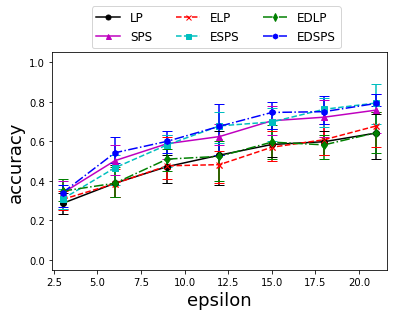

In [9]:
N = 150; m = 5

acc = np.zeros((7,6))
max_acc = np.zeros((7,6)); min_acc = np.ones((7,6))
sum_acc = np.zeros((7,6))

epsilon = np.zeros(7)
y_err = np.zeros((2,7,6))

for i in range(7):
    epsilon[i] = 3*(i+1)

CDF = np.zeros(2001)
for i in range(2001):
    CDF[i] = cdf((i-1000)/100,h4)[0]

for j in range(5):
    acc = accuracy(N,m,CDF)
    for i in range(7):
        for k in range(6):
            max_acc[i][k] = max(max_acc[i][k], acc[i][k])
            min_acc[i][k] = min(min_acc[i][k], acc[i][k])
            sum_acc[i][k] += acc[i][k]
    print(acc)
acc = sum_acc/5

for k in range(6):
    y_err[0,:,k] = acc[:,k] - min_acc[:,k]
    y_err[1,:,k] = max_acc[:,k] - acc[:,k]

print(acc)
fig = plt.figure()
plt.ylim(-0.05, 1.05)
plt.xlim(2.4, 21.6)
plt.errorbar(epsilon, acc[:,0], yerr = y_err[:,:,0], capsize=5, fmt='o', ecolor='black', markeredgecolor = "black", color='black')
plt.plot(epsilon, acc[:,0], marker="o", markersize=5, color = "black", linestyle = "-", label = "LP")
plt.errorbar(epsilon, acc[:,3], yerr = y_err[:,:,3], capsize=5, fmt='^', ecolor='m', markeredgecolor = "m", color='m')
plt.plot(epsilon, acc[:,3], marker="^", markersize=5, color = "m", linestyle = "-", label = "SPS")
plt.errorbar(epsilon, acc[:,1], yerr = y_err[:,:,1], capsize=5, fmt='x', ecolor='red', markeredgecolor = "red", color='red')
plt.plot(epsilon, acc[:,1], marker="x", markersize=5, color = "red", linestyle = "--", label = "ELP")
plt.errorbar(epsilon, acc[:,4], yerr = y_err[:,:,4], capsize=5, fmt='s', ecolor='c', markeredgecolor = "c", color='c')
plt.plot(epsilon, acc[:,4], marker="s", markersize=5, color = "c", linestyle = "--", label = "ESPS")
plt.errorbar(epsilon, acc[:,2], yerr = y_err[:,:,2], capsize=5, fmt='d', ecolor='green', markeredgecolor = "green", color='green')
plt.plot(epsilon, acc[:,2], marker="d", markersize=5, color = "green", linestyle = "dashdot", label = "EDLP")
plt.errorbar(epsilon, acc[:,5], yerr = y_err[:,:,5], capsize=5, fmt='h', ecolor='blue', markeredgecolor = "blue", color='blue')
plt.plot(epsilon, acc[:,5], marker="h", markersize=5, color = "blue", linestyle = "dashdot", label = "EDSPS")
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=3, fontsize=12)
plt.xlabel("epsilon", fontsize = 18)
plt.ylabel("accuracy", fontsize = 18)
fig.savefig("Accuracy_two-sided_m=5.png")
fig.savefig("figs/Accuracy_two-sided_m=5.eps", bbox_inches="tight", pad_inches=0.05)